<a href="https://colab.research.google.com/github/HEISENBERG-PV/BACKEND_PROJECT/blob/main/rf_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')

In [ ]:
df.shape

(5000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# **DATA CLEANING**

Physical_Activity_Hours me min negative aa rha h which is possible

---


that's why hm clip(lower=0) use krnge which is used to convert any un-realistic value ko realistic value

In [ ]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751400,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.667274,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(4998, 13)

# **CHECK SKEWNESS**

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

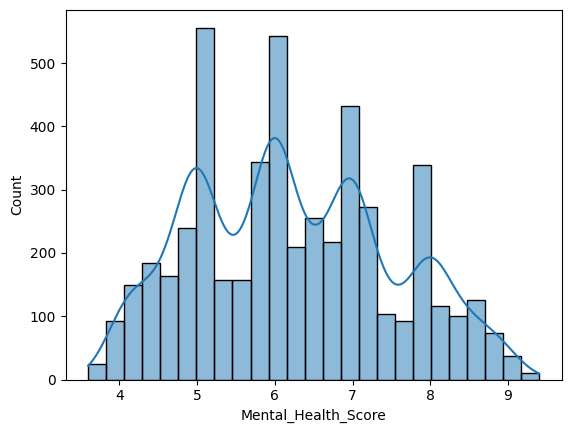

In [ ]:
sns.histplot(df['Mental_Health_Score'], kde=True)

In [ ]:
num_cols = df.select_dtypes(include='number' )
num_cols.skew()
# if skew value
#  - near to 0 --> centralized
#  - negative --> left skewed
#  - positive --> right skewed

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


# **FEATURE ENGINEERING**

df['country'] me 110+ values h, isilye top 10 countries lenge or baaki ko other catagory me dal denge

In [ ]:
top_countries = df['Country'].value_counts().index[:10].to_list()

In [ ]:
def grp_countries(Country):
  if Country in top_countries:
    return Country
  else :
    return 'Other'

In [ ]:
df['Country'] = df['Country'].apply(grp_countries)
df['Country'].value_counts()

,count
Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 546.7+ KB


# **PIPELINE AND COLUMN TRANSFORMER**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 546.7+ KB


In [ ]:
skewed_col = ['Study_Hours']  # log transformation to fix skewness
numeric_cols = ['Age', 'Physical_Activity_Hours', 'Daily_Unlocks', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'] # onehotencoding
ordinal_col = ['Stress_Level']  # label encoding to preserve the order
normal_col = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use']

feature_col = skewed_col + numeric_cols + ordinal_col + normal_col
target_col = 'Mental_Health_Score'
X = df[feature_col]
y = df[target_col]


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
df['Stress_Level'].value_counts()

,count
Stress_Level,
Very High,1621
High,1439
Medium,1295
Low,643


**PIPELINE**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler


#skewness --> np.log1p
skew_pipeline = Pipeline(steps=[
    ('log_transformer', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

#numeric  --> standscaler()
numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

#ordinal  --> ordinalEncoder() to preserve order
from sklearn.preprocessing import OrdinalEncoder
ordinal_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#nominal  --> onehotencoder() bcoz we don't have to preserve the order
from sklearn.preprocessing import OneHotEncoder
nominal_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])



# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import FunctionTransformer
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.preprocessing import OneHotEncoder
# skewed_pipeline = Pipeline(steps=[
#     ('log_treansformer', FunctionTransformer(np.log1p)),
#     ('std', StandardScaler())
# ])

# numeric_pipeline = Pipeline(steps=[
#     ('std', StandardScaler())
# ])

# ordinal_pipeline = Pipeline(steps=[
#     ('ordinal', OrdinalEncoder(categories=['low', 'mid', 'high', 'very high']))
# ])

# nominal_pipeline = Pipeline(steps=[
#     ('onehot', OneHotEncoder())
# ])

# **ColumnTransformer**
it is used to defines konsi pipeline me konsa feature bhjna h



In [ ]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
    #(konsi pipeline, konsa feature)
      ('Skewed_Pipeline', skew_pipeline, skewed_col),
      ('Num_Pipeline', numeric_pipeline, numeric_cols),
      ('Ordinal_Pipeline', ordinal_pipeline, ordinal_col),
      ('Nominal_Pipeline', nominal_pipeline, normal_col)
])

In [ ]:
X_train.shape


(3498, 12)

# **Baseline Model : Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  r2_score, mean_absolute_error, mean_squared_error
lr_pipeline = Pipeline(steps=[
    ('Preprocessor', preprocessor),
    ('Lr', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred_testing = lr_pipeline.predict(X_test)
lr_pred_training = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_pred_testing)
lr_r2_training = r2_score(y_train, lr_pred_training)
lr_mean_abs_err = mean_absolute_error(y_test, lr_pred_testing)

print(f"Accuracy for testing is : {lr_r2_testing}")
print(f"Accuracy for training is : {lr_r2_training}")
print(f"Mean absoulte error : {lr_mean_abs_err}")

Accuracy for testing is : 0.739794461743302
Accuracy for training is : 0.7236771199387539
Mean absoulte error : 0.5361775634720183


# **Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('Preprocessor', preprocessor),
    ('algo', RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)
rf_pred_testing = rf_pipeline.predict(X_test)
rf_pred_training = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_pred_testing)
rf_r2_training = r2_score(y_train, rf_pred_training)
rf_mean_abs_err = mean_absolute_error(y_test, rf_pred_testing)

print(f"Accuracy for testing is : {rf_r2_testing}")
print(f"Accuracy for training is : {rf_r2_training}")
print(f"Mean absoulte error : {rf_mean_abs_err}")

Accuracy for testing is : 0.8783275586381852
Accuracy for training is : 0.9809307917137926
Mean absoulte error : 0.34721583333333345


# **HyperParameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'algo__n_estimators'      : [100, 200, 300],
    'algo__max_depth'         : [5, 10, 15],
    'algo__min_samples_split' : [2, 5, 10],
    'algo__min_samples_leaf'  : [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator             = rf_pipeline,
    param_distributions   = param_grid,
    n_iter                = 10,
    scoring               = 'r2',
    random_state          = 42,
    n_jobs                = -1,
    cv                    = 5
)

rf_hyp = random_search.fit(X_train, y_train)

In [ ]:
random_search.best_params_

{'algo__n_estimators': 200,
 'algo__min_samples_split': 10,
 'algo__min_samples_leaf': 2,
 'algo__max_depth': 15}

In [ ]:
rf_best_pred = random_search.best_estimator_.predict(X_test)
print(f' random forest predict r2score after hypertuning is : {r2_score(y_test, rf_best_pred)}')
print(f' random forest predict mae after hypertuning is : {mean_absolute_error(y_test, rf_best_pred)}')

 random forest predict r2score after hypertuning is : 0.8584072161468927
 random forest predict mae after hypertuning is : 0.3797503235492348


# **Model Evaluation**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "Linear Regression": lr_pipeline,
    "Random Forest (default)": rf_pipeline,
    "Random Forest (tuned)": rf_hyp
}

results = []

for name, model in models.items():

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "R2 Train": r2_score(y_train, y_train_pred),
        "R2 Test": r2_score(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
    })

results_df = pd.DataFrame(results)

print(results_df)

                     Model  R2 Train   R2 Test       MAE      RMSE
0        Linear Regression  0.723677  0.739794  0.536178  0.676032
1  Random Forest (default)  0.980931  0.878328  0.347216  0.462280
2    Random Forest (tuned)  0.935572  0.857012  0.380676  0.501140


# **Save the Model**
save the preprocessing and model together as a single file
using joblib.dump()

In [ ]:
import joblib
joblib.dump(rf_pipeline, "Mental_health_MLmodel.pkl")

['Mental_health_MLmodel.pkl']